Total num of events :  100
[1, 0, 0, 0, 0, 0, 2, 0, 0, 5, 0, 0, ..., 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2]
================= 1 : Length = 31 ======================
[1, 0, 0, 0, 3, 0, 0, 0, 4, 0, 0, 0, 0, ..., 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1]
================= 2 : Length = 22 ======================
[3, 0, 0, 14, 0, 0, 31, 0, 0, 57, 0, 0, ..., 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 1]
================= 3 : Length = 33 ======================
[2, 0, 23, 0, 26, 0, 36, 0, 49, 0, 0, 82, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
================= 4 : Length = 29 ======================


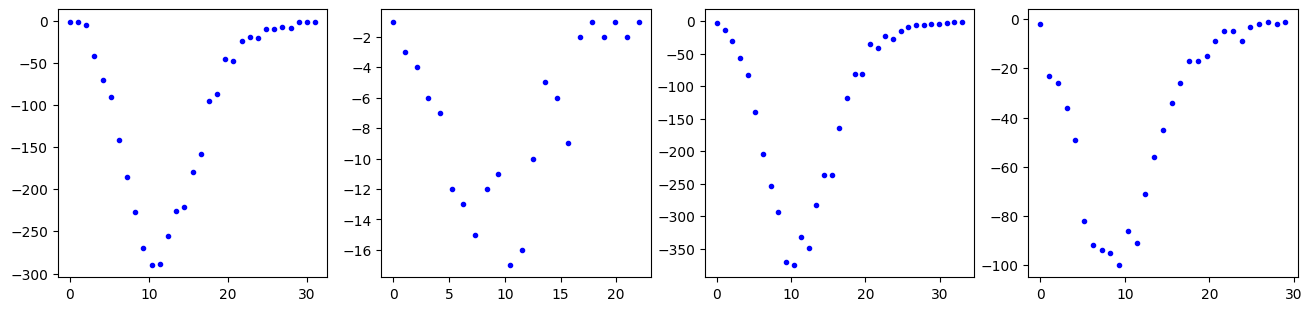

In [1]:

#For PSD simulation code
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak # Added explicit import for best practice
from scipy.optimize import curve_fit

def max_normalize(data):
    """Scales data by the absolute maximum value."""
    # Find the largest absolute value in the dataset
    max_abs_val = np.max(np.abs(data))
    if max_abs_val == 0:
        return np.zeros_like(data)
    # Divide all data points by the absolute maximum
    return data / max_abs_val

def double_exp(t, A1, tau1, A2, tau2, t0, baseline):
    t_shift = np.maximum(t - t0, 0)  # enforce zero before start
    return baseline + A1 * np.exp(t_shift / tau1) + A2 * np.exp(-t_shift / tau2)



# --- 1. CONFIGURATION ---
#FILE_PATH="/home/rsehgal/shared/"
FILE_PATH="/Users/rsehgal/Codes/G4Workshop_Calicut/PSD/"
#SOURCE_FILE_PATH = FILE_PATH+'buildNeutron/neutron.mac.root' 
#SOURCE_FILE_PATH = FILE_PATH+'build/gamma.mac.root' 
SOURCE_FILE_PATH = FILE_PATH+'build/neutron.mac.root' 
#SOURCE_FILE_PATH = FILE_PATH+'DataF_Bar_Na22_2min.root' 
TREE_NAME = "ftree"

# --- 2. FILE & TREE ACCESS ---
# Use 'with' for safe file handling
segregatedCharge=[]
hei=[]
rows=5
cols=5
plotPulses=True
listOfPulses=[]
plt.figure(figsize=(16,16))
#branchList=['Energy','EnergyShort','Samples']
branchList=['Samples']
counter=0
with uproot.open(SOURCE_FILE_PATH) as file:
    tree = file[TREE_NAME]
    

    # --- 3. DATA READING (Optimized) ---
    # Read only the first event (entry_stop=1) and the 'Samples' branch
    if plotPulses:
        data = tree.arrays(
            branchList, 
            entry_start=0, 
            entry_stop=100, 
            library="ak"
        )
    else:
        data = tree.arrays(
            branchList,
            #entry_start=0, 
            #entry_stop=1000, 
            library="ak"
        )
    print("Total num of events : ",len(data))

    
    #for pulseNum in range(0,len(data)):
    firstWave=np.array([])
    for pulseNum in range(0,4):
        counter+=1
        #print(data[pulseNum]["Samples"])
        
        timePts=np.linspace(0,len(data[pulseNum]["Samples"]),len(data[pulseNum]["Samples"]))
        #plt.plot(timePts,data[1]["Samples"])
        
        counts, bin_edges = np.histogram(data[pulseNum]["Samples"], bins=100)
        #print(counts)
    
        print(counts)
        mask = counts>0
        counts = counts[mask]
        counts = -1.*counts
        if counter == 1:
            firstWave=counts
        
        counts = counts.tolist()
        time_points=np.linspace(0,len(counts),len(counts))
        plt.subplot(4,4,counter)
        #plt.plot(time_points,counts,"r.-")
        print(f"================= {counter} : Length = {len(counts)} ======================")
        plt.scatter(time_points,counts,marker=".",color="blue")

    
        

================= FirstWave Length = 31 ======================
[-0.00128365 -0.00256731 -0.00641826 -0.05391341 -0.08985568 -0.11681239
 -0.18227867 -0.23875939 -0.29138915 -0.34658621 -0.37225926 -0.37097561
 -0.32861507 -0.29010549 -0.28368723 -0.22977382 -0.20281712 -0.121947
 -0.11167778 -0.05776437 -0.06161533 -0.03080766 -0.0243894  -0.02695671
 -0.01283653 -0.01283653 -0.00898557 -0.01155287 -0.00256731 -0.00128365
 -0.00256731  0.        ]
Figure(2210.55x1956.5)


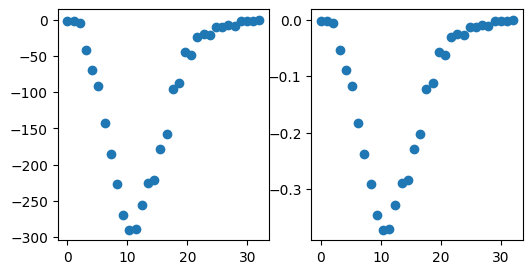

In [38]:
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister, Gate
from qiskit_aer import AerSimulator



firstWaveList=firstWave.tolist()
firstWaveList.append(0)
pulse_data=np.array(firstWaveList)

plt.figure(figsize=(6,3))

time_points=np.linspace(0,len(pulse_data),len(pulse_data))
print(f"================= FirstWave Length = {len(firstWave)} ======================")

plt.subplot(1,2,1)
plt.scatter(time_points,pulse_data)



# 1. Assume 'pulse_data' is your array of 1024 voltage samples
#pulse_data = np.array([...]) # Your n or gamma pulse

# 2. Normalize the pulse (The sum of squares must equal 1)
norm = np.linalg.norm(pulse_data)
state_vector = pulse_data / norm
print(state_vector)
plt.subplot(1,2,2)
plt.scatter(time_points,state_vector)


# 3. Initialize a 10-qubit circuit with this state
# This automatically calculates the necessary RY and CNOT gates
qc = QuantumCircuit(5)
qc.initialize(state_vector, range(5))
decomposed_qc = qc.decompose()
decomposed_qc = decomposed_qc.decompose()
decomposed_qc = decomposed_qc.decompose()
decomposed_qc = decomposed_qc.decompose()
decomposed_qc = decomposed_qc.decompose()
decomposed_qc = decomposed_qc.decompose()

# Draw the circuit
print(decomposed_qc.draw(output="mpl",filename="qwave.png"))

simulator = AerSimulator()
#circ_compiled = transpile(qc, simulator)
#circ_compiled.draw(output='mpl', filename='qwave.png')

# The circuit now 'is' the pulse in the Hilbert space.
